# Model-Tests

In [31]:
%matplotlib inline
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("nelgiriyewithana/world-stock-prices-daily-updating")

print("Path to dataset files:", path)
data_path = path+"\World-Stock-Prices-Dataset.csv"
data = pd.read_csv(data_path)

<>:9: SyntaxWarning: invalid escape sequence '\W'
<>:9: SyntaxWarning: invalid escape sequence '\W'
C:\Users\s3phi\AppData\Local\Temp\ipykernel_38360\942347233.py:9: SyntaxWarning: invalid escape sequence '\W'
  data_path = path+"\World-Stock-Prices-Dataset.csv"


Path to dataset files: C:\Users\s3phi\.cache\kagglehub\datasets\nelgiriyewithana\world-stock-prices-daily-updating\versions\385


In [32]:
data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Brand_Name,Ticker,Industry_Tag,Country,Capital Gains
0,2025-06-20 00:00:00-04:00,6.170000,6.305000,6.080000,6.180000,13221100.0,0.0,0.0,peloton,PTON,fitness,usa,NaN
1,2025-06-20 00:00:00-04:00,100.239998,100.660004,98.360001,98.519997,1491100.0,0.0,0.0,crocs,CROX,footwear,usa,NaN
2,2025-06-20 00:00:00-04:00,69.089996,69.559998,68.779999,68.839996,40841100.0,0.0,0.0,the coca-cola company,KO,food & beverage,usa,NaN
3,2025-06-20 00:00:00-04:00,112.320000,112.809998,111.769997,112.059998,31500.0,0.0,0.0,adidas,ADDYY,apparel,germany,NaN
4,2025-06-20 00:00:00-04:00,297.579987,299.750000,296.640015,298.589996,5687000.0,0.0,0.0,american express,AXP,finance,usa,NaN


In [ ]:
#arr = data["Brand_Name"].unique()
#for i in arr:
#    print(i)

In [22]:
df = pd.DataFrame(data)
df_apple = df.loc[df["Brand_Name"] == "google", ["Date", "Close", "Brand_Name"]]
display(df_apple)

,Date,Close,Brand_Name
38,2025-06-20 00:00:00-04:00,166.639999,google
67,2025-06-18 00:00:00-04:00,173.320007,google
151,2025-06-18 00:00:00-04:00,173.320007,google
189,2025-06-17 00:00:00-04:00,175.949997,google
286,2025-06-16 00:00:00-04:00,176.770004,google
...,...,...,...
269136,2004-08-25 00:00:00-04:00,2.652653,google
269189,2004-08-24 00:00:00-04:00,2.624374,google
269217,2004-08-23 00:00:00-04:00,2.737738,google
269263,2004-08-20 00:00:00-04:00,2.710460,google


In [23]:
df_apple_preproc = df_apple.rename(columns={"Date": "timestamp", "Close": "target", "Brand_Name": "item_id"})
df_apple_preproc["item_id"] = df_apple_preproc['item_id'].astype("string")
df_apple_preproc["timestamp"] = df_apple_preproc['timestamp'].astype("string")
timecut = df_apple_preproc["timestamp"].str.slice(stop=10) #Cut hh:mm:ss and timezone
df_apple_preproc["timestamp"] = timecut
df_apple_preproc["timestamp"] = pd.to_datetime(timecut) #convert string into datetime64
df_apple_reordered =  df_apple_preproc[['item_id', 'timestamp', 'target']] #Reordering columns
df_irregular = TimeSeriesDataFrame(
    pd.DataFrame(df_apple_reordered)
)
df_regular = df_irregular.convert_frequency(freq="D")
df_filled = df_regular.fill_missing_values()
data = TimeSeriesDataFrame.from_data_frame(
    df = df_filled,
    id_column="item_id",
    timestamp_column="timestamp"
)

In [27]:
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

prediction_length = 10
train_data, test_data = data.train_test_split(prediction_length)

predictor = TimeSeriesPredictor(prediction_length=prediction_length, freq="D").fit(
    train_data, presets="bolt_base", hyperparameters={"Chronos": {"fine_tune": True, "fine_tune_lr": 1e-5, "fine_tune_steps": 6000}},
    time_limit=60,
)

Beginning AutoGluon training... Time limit = 60s
AutoGluon will save models to 'c:\workspace\CrimeMap\AutogluonModels\ag-20250622_074946'
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.1
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          8
GPU Count:          0
Memory Avail:       2.39 GB / 15.70 GB (15.2%)
Disk Space Avail:   39.44 GB / 475.50 GB (8.3%)
Setting presets to: bolt_base

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WQL,
 'freq': 'D',
 'hyperparameters': {'Chronos': {'fine_tune': True,
                                 'fine_tune_lr': 1e-05,
                                 'fine_tune_steps': 6000}},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 10,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'skip_model_selection': True,

Model not specified in predict, will default to the model with the best validation score: Chronos[autogluon__chronos-bolt-small]


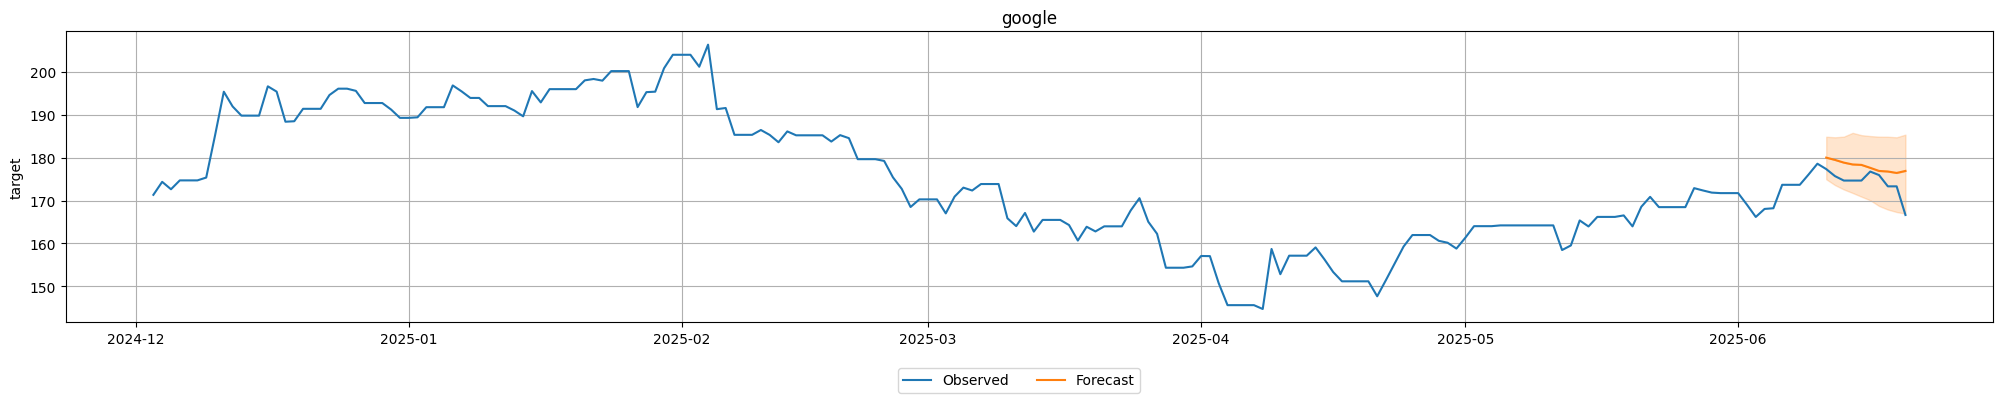

In [28]:
predictions = predictor.predict(train_data)
predictor.plot(
    data=data,
    predictions=predictions,
    item_ids=data.item_ids[:2],
    max_history_length=200,
);